In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
# 1. Load Dataset
# =====================================================
dataset = tfds.load('cats_vs_dogs', as_supervised=True)['train']

IMG_SIZE = 224
BATCH_SIZE = 32

def preprocess(img, label):
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_input(img)
    return img, tf.one_hot(label, 2)

dataset = dataset.map(preprocess).shuffle(1000).batch(BATCH_SIZE)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.JLF2FR_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [ ]:
# 2. Load Pretrained VGG16 Model
# =====================================================
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 3. Compile & Train
# =====================================================
model.compile(optimizer=Adam(1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(dataset, epochs=3)

Epoch 1/3
727/727 ━━━━━━━━━━━━━━━━━━━━ 146s 193ms/step - accuracy: 0.9893 - loss: 0.0657
Epoch 2/3
727/727 ━━━━━━━━━━━━━━━━━━━━ 140s 189ms/step - accuracy: 0.9929 - loss: 0.0339
Epoch 3/3
727/727 ━━━━━━━━━━━━━━━━━━━━ 140s 190ms/step - accuracy: 0.9949 - loss: 0.0202


In [ ]:
# 4. Evaluate
# =====================================================
loss, acc = model.evaluate(dataset)
print("Accuracy:", acc)

727/727 ━━━━━━━━━━━━━━━━━━━━ 144s 193ms/step - accuracy: 0.9996 - loss: 0.0012
Accuracy: 0.9996131062507629


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


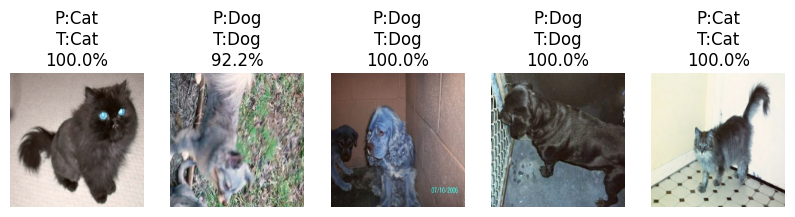

In [ ]:
# 5. Prediction Visualization
# =====================================================
class_names = ['Cat', 'Dog']

for images, labels in dataset.take(1):
    preds = model.predict(images)

    plt.figure(figsize=(10,5))

    for i in range(5):
        pred = np.argmax(preds[i])
        true = np.argmax(labels[i])
        conf = preds[i][pred] * 100

        img = images[i].numpy()
        img = (img - img.min()) / (img.max() - img.min())

        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.title(f"P:{class_names[pred]}\nT:{class_names[true]}\n{conf:.1f}%")
        plt.axis('off')

    plt.show()